# Effective dimensionality $d_{\rm eff}(x,\tau)$ from MGD's $\Theta_{\rm reg}$ (turbulence, $M{=}256$)

Computes Guth et al.'s local effective dimensionality, **denoiser form and
energy form**, on the completed $M{=}256$ turbulence runs
(`turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_{300..350}`),
purely as post-processing of each seed's already-fitted $\Theta_{\rm reg}$ --
no new SDE / guided-transport run. Derivation and the Guth $\leftrightarrow$
MGD dictionary: `notes/effective_dimension_MGD.tex`. Implementation:
`codes/effective_dimension.py`.

Evaluation points reuse `turbulence/turb_theta_reg_rare_typical.ipynb`'s own
typical/rare split (`extract_rare_typical`, 95th-percentile max-|acceleration|
criterion) on the SAME data ordering, so results here are directly comparable
to that notebook's.

**`SMOKE_TEST = True` below is the shipped default** (few seeds, few $t$
nodes, small Monte-Carlo count) -- it runs in well under a minute and only
checks the pipeline is wired correctly, it is NOT a real sweep. Set
`SMOKE_TEST = False` for the real 49-seed sweep over the full $\Theta_{\rm
reg}$ grid; that is compute-heavy (up to $49 \times 197$ node-evaluations,
each a batched $\varphi/\nabla\varphi$ call) and better run with a GPU
(Jean Zay) than on a laptop CPU.


In [1]:
import sys, os, re, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

root = Path().resolve()          # turbulence/
sys.path.insert(0, str(root / '../codes'))
sys.path.insert(0, str(root / '../data'))

from filters_bank import return_Filters
from potentials_builder import get_1d_potentials
from utils import split_periodize_reshape, normalize
from utils_experiment import try_load_experiment
from ortho_wavelet.ReadyToUseWavelets import DefineWavelet
from effective_dimension import (
    reconstruct_t_reg, load_fitted_potentials, load_or_recompute_m_t,
    h_bound_at, extract_rare_typical, denoiser_d_eff, energy_d_eff,
    alpha_of_t, tau_of_t,
)
from data_loader import load_turbulence_1d

# RUN_LOCATION: same convention as turb_theta_reg_rare_typical.ipynb --
# load_turbulence_1d()'s default path is Jean-Zay-only (/lustre/...); flip
# TURBULENCE_1D_DATA_PATH to the local copy when running off the cluster.
RUN_LOCATION = "local"   # "local" or "jean_zay"
if RUN_LOCATION == "local":
    local_turbulence_path = (root / "../data/data_files/turbulence_1d_period.pt").resolve()
    if local_turbulence_path.exists():
        os.environ["TURBULENCE_1D_DATA_PATH"] = str(local_turbulence_path)
    else:
        print(f"WARNING: {local_turbulence_path} not found -- load_turbulence_1d() "
              f"will fall back to its Jean Zay default path and fail locally.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', root)


device: cpu | /home/chiaraz/phd/MGD-for-Maximum-Entropy-Generation/turbulence


## Config -- matches the d=256 turbulence run family, and the SMOKE_TEST toggle

In [2]:
J, Q, M = 8, 3, 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 5e-07
n_subsample = 200          # --n_subsample used by these runs (config.json)
regularization = 1e-2

terms = [
    "L_6", "L_6_psi", "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1", "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK", "Scalar_morlet_gaussianK",
]

SEED_PATTERN = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_(\d+)_terms2f1130a8_20260728_1232$"
)
SEED_RANGE = range(300, 350)

# ----------------------------------------------------------------------------
SMOKE_TEST = True   # <-- flip to False for the real sweep (see markdown above)
# ----------------------------------------------------------------------------
if SMOKE_TEST:
    N_SEEDS       = 2          # how many discovered seeds to actually process
    N_T_SUB       = 12         # subsample Theta_reg's 197 nodes down to this many
    N_MC          = 8          # Monte-Carlo draws per (t, x) in denoiser/energy_d_eff
    N_PER_CATEGORY = 2         # typical/rare points each
    M1_RECOMPUTE_SUBSET = 300  # x1 rows used when m_t has to be recomputed
else:
    N_SEEDS       = None       # None = all discovered seeds
    N_T_SUB       = None       # None = full Theta_reg grid (197 nodes)
    N_MC          = 128
    N_PER_CATEGORY = 5
    M1_RECOMPUTE_SUBSET = 2000

print(f"SMOKE_TEST={SMOKE_TEST}  N_SEEDS={N_SEEDS} N_T_SUB={N_T_SUB} "
      f"N_MC={N_MC} N_PER_CATEGORY={N_PER_CATEGORY}")


SMOKE_TEST=True  N_SEEDS=2 N_T_SUB=12 N_MC=8 N_PER_CATEGORY=2


## Data (shared across all seeds -- these runs all fit the same `x1`)

In [3]:
W = DefineWavelet('Db', m=3, device=device)
Data_raw = load_turbulence_1d().to(device)
Data = split_periodize_reshape(Data_raw, 1024)
scales = int(np.log2(Data.shape[-1] / M))
for _ in range(scales):
    Data = W.decompose(Data)[1]
x1 = normalize(Data[:n1]).to(device)
d = int(np.prod(x1.shape[1:]))
print('Data:', tuple(Data.shape), '| x1:', tuple(x1.shape), '| d =', d)


Data: (10000, 1, 256) | x1: (5000, 1, 256) | d = 256


## Rare / typical split and fixed evaluation points

Same criterion, same `Data[:n1]` ordering as
`turb_theta_reg_rare_typical.ipynb`'s `extract_rare_typical` -- reused
verbatim from `codes/effective_dimension.py` so the indices line up with
that notebook's. The SAME points are evaluated for every seed (fixed RNG),
so per-seed $d_{\rm eff}$ curves at a given point are directly comparable.


In [4]:
idx_typical, idx_rare, split_info = extract_rare_typical(Data[:n1], criterion='percentile', percentile=95)
print(f"typical {len(idx_typical)}, rare {len(idx_rare)}   {split_info}")

rng = np.random.default_rng(0)
picked_typical = rng.choice(idx_typical, size=N_PER_CATEGORY, replace=False)
picked_rare = rng.choice(idx_rare, size=N_PER_CATEGORY, replace=False)
eval_idx = np.concatenate([picked_typical, picked_rare])
eval_category = ['typical'] * N_PER_CATEGORY + ['rare'] * N_PER_CATEGORY
x_eval = x1[eval_idx]
print('x_eval:', tuple(x_eval.shape), '| categories:', eval_category)


typical 4750, rare 250   {'accel_std': 0.3395721912384033, 'percentile': 95, 'cutoff': np.float32(3.5330675)}
x_eval: (4, 1, 256) | categories: ['typical', 'typical', 'rare', 'rare']


## Seed discovery (same regex/range as `turb_theta_reg_rare_typical.ipynb`)

In [5]:
samples_dir = root / 'saved_results' / 'samples'
all_folders = os.listdir(samples_dir)
seed_configs = []
for folder in sorted(all_folders):
    m = SEED_PATTERN.match(folder)
    if not m:
        continue
    seed_val = int(m.group(1))
    if seed_val not in SEED_RANGE:
        continue
    seed_configs.append((seed_val, folder))
seed_configs.sort(key=lambda p: p[0])
if N_SEEDS is not None:
    seed_configs = seed_configs[:N_SEEDS]
print(f"Found {len(seed_configs)} seed(s) to process: {[s for s, _ in seed_configs]}")


Found 2 seed(s) to process: [300, 301]


## Potential skeleton (unfitted) -- fitted state is loaded per seed

`Scalar_psi_gaussianK`/`Scalar_morlet_gaussianK` auto-prune during `fit()`
(100$\to$70 and 36$\to$27 active statistics for this config); the pruned,
fitted state must be loaded from each seed's own `fitted_potentials/`
(matches `SDE.__init__`'s own load-or-fit logic), otherwise `r` and every
theta index are wrong.


In [6]:
filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)
potentials_skeleton = get_1d_potentials(
    terms, J, filters, Q, filters_Q=filters_Q, filters_Phi=filters_Phi,
    scalar_param=None, parallel=False,
)
print('unfitted r =', sum(p.num_coefficients for p in potentials_skeleton.values()))


unfitted r = 311


## Per-seed computation

For each seed: load $\Theta_{\rm reg}$, reconstruct $t_{\rm reg}$
(`reconstruct_t_reg` -- these runs predate saving it directly), load the
seed's fitted potentials, get $m_t$ (`aux_moments` if present, else
recomputed from `x1` + schedule -- no SDE rerun either way), build
$H_{\rm bound}(t)$ from the saved `dH_t_bound`, then evaluate both
`denoiser_d_eff` and `energy_d_eff` at the fixed evaluation points.


In [7]:
base = root / 'saved_results'
rows = []
t0 = time.time()

for seed_val, resolved_config in seed_configs:
    t_seed0 = time.time()
    theta_reg_path = base / 'lagrange_multipliers_regularised' / resolved_config
    t_fine_path = base / 'sampling_times' / resolved_config
    dH_path = base / 'entropy_bounds' / resolved_config
    if not (theta_reg_path.exists() and t_fine_path.exists() and dH_path.exists()):
        print(f"seed {seed_val}: missing saved results, skipping")
        continue

    Theta_reg = torch.load(theta_reg_path, map_location='cpu').double()
    t_fine = torch.load(t_fine_path, map_location='cpu').numpy().astype(np.float64)
    dH_fine = torch.load(dH_path, map_location='cpu').numpy().astype(np.float64)

    t_reg_full = reconstruct_t_reg(t_fine, n_subsample=n_subsample)
    if len(t_reg_full) != Theta_reg.shape[0]:
        print(f"seed {seed_val}: reconstructed t_reg length {len(t_reg_full)} != "
              f"Theta_reg {Theta_reg.shape[0]}, skipping (grid mismatch)")
        continue

    if N_T_SUB is not None and N_T_SUB < len(t_reg_full):
        sub = np.linspace(0, len(t_reg_full) - 1, N_T_SUB).round().astype(int)
        sub = np.unique(sub)
    else:
        sub = np.arange(len(t_reg_full))
    t_reg = t_reg_full[sub]
    theta_reg = Theta_reg[sub]

    potentials_dir = root / 'experiments' / resolved_config / 'fitted_potentials'
    potentials = load_fitted_potentials(potentials_skeleton, potentials_dir, device=device)
    r = sum(p.num_coefficients for p in potentials.values())

    aux_path = base / 'aux_moments' / f'{resolved_config}_aux_moments.pt'
    m_t, m_t_source = load_or_recompute_m_t(
        aux_path, t_fine, t_reg, potentials, x1[:M1_RECOMPUTE_SUBSET], n_mc_noise=1,
    )
    H_bound_t_reg = h_bound_at(t_fine, dH_fine, t_reg, d=d)

    gen = torch.Generator(device=x_eval.device).manual_seed(seed_val)
    d_den = denoiser_d_eff(x_eval, theta_reg, t_reg, potentials, n_mc=N_MC, generator=gen)
    d_en = energy_d_eff(x_eval, theta_reg, t_reg, potentials, m_t, H_bound_t_reg, d=d,
                         n_mc=N_MC, generator=gen)

    tau_reg = tau_of_t(t_reg)
    for j in range(len(t_reg)):
        for k in range(x_eval.shape[0]):
            rows.append(dict(
                seed=seed_val, config=resolved_config, r=r, m_t_source=m_t_source,
                point_idx=int(eval_idx[k]), category=eval_category[k],
                t=float(t_reg[j]), tau=float(tau_reg[j]),
                d_eff_denoiser=float(d_den[j, k]), d_eff_energy=float(d_en[j, k]),
            ))

    print(f"seed {seed_val}: {len(t_reg)} t-nodes x {x_eval.shape[0]} points, "
          f"r={r}, m_t={m_t_source}  [{time.time()-t_seed0:.1f}s, total {time.time()-t0:.1f}s]")

results_df = pd.DataFrame(rows)
print(f"\nTotal: {len(results_df)} rows, {results_df['seed'].nunique()} seeds, "
      f"{time.time()-t0:.1f}s")
results_df.head()


seed 300: 12 t-nodes x 4 points, r=272, m_t=recomputed  [16.0s, total 16.0s]


seed 301: 12 t-nodes x 4 points, r=272, m_t=recomputed  [16.1s, total 32.1s]

Total: 96 rows, 2 seeds, 32.2s


,seed,config,r,m_t_source,point_idx,category,t,tau,d_eff_denoiser,d_eff_energy
0,300,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,272,recomputed,4254,typical,0.019950,1017.675744,23.217066,1.161206
1,300,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,272,recomputed,3185,typical,0.019950,1017.675744,25.044844,0.868481
2,300,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,272,recomputed,1600,rare,0.019950,1017.675744,22.681404,1.481911
3,300,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,272,recomputed,1473,rare,0.019950,1017.675744,22.902538,-0.549158
4,300,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,272,recomputed,4254,typical,0.190045,10.560767,20.502871,2.163113


## Save the aggregate results (not under `saved_results/` -- see CLAUDE.md write-protection on that tree)

In [8]:
out_dir = root / 'deff_results'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f'd_eff_smoke{SMOKE_TEST}_nseeds{results_df["seed"].nunique()}.csv'
results_df.to_csv(out_path, index=False)
print('saved to', out_path)


saved to /home/chiaraz/phd/MGD-for-Maximum-Entropy-Generation/turbulence/deff_results/d_eff_smokeTrue_nseeds2.csv


## Per-seed curves, typical vs rare

Each thin line is one (seed, point); the thick line is the median across
everything in that category, at each $\tau$ node. $x$-axis is $\tau$ (log
scale, decreasing left to right along $t$: $\tau\to\infty$ at $t\to0$,
$\tau\to0$ at $t\to1$).


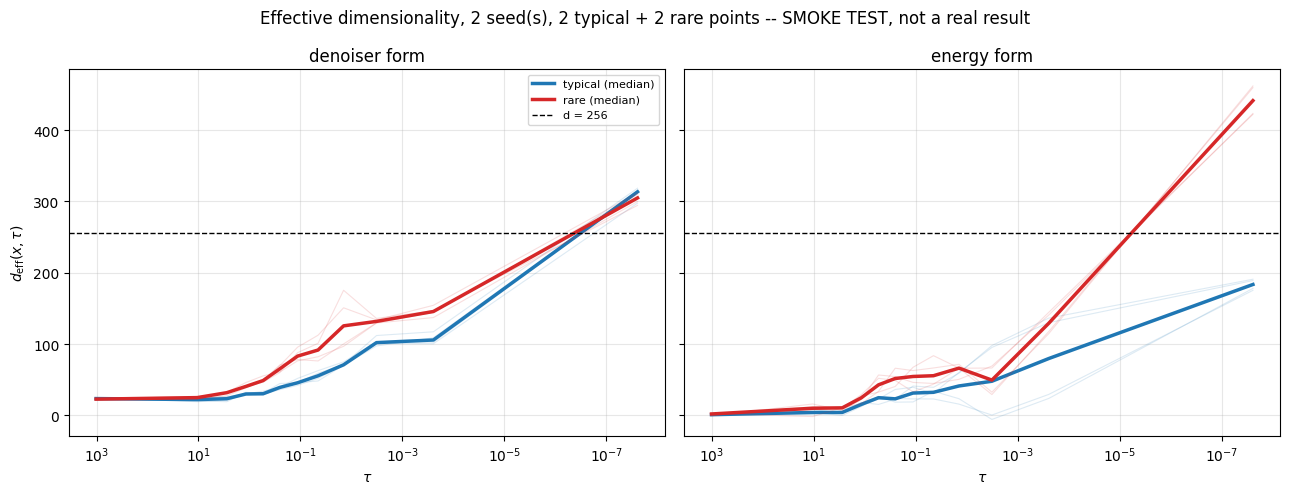

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
colors = {'typical': 'tab:blue', 'rare': 'tab:red'}

for ax, col, title in [(axes[0], 'd_eff_denoiser', 'denoiser form'),
                        (axes[1], 'd_eff_energy', 'energy form')]:
    for cat in ['typical', 'rare']:
        sub = results_df[results_df.category == cat]
        for (seed, idx), g in sub.groupby(['seed', 'point_idx']):
            g = g.sort_values('tau')
            ax.plot(g['tau'], g[col], color=colors[cat], alpha=0.15, lw=0.8)
        med = sub.groupby('tau')[col].median().sort_index()
        ax.plot(med.index, med.values, color=colors[cat], lw=2.5, label=f'{cat} (median)')
    ax.axhline(d, color='k', ls='--', lw=1, label=f'd = {d}')
    ax.set_xscale('log')
    ax.invert_xaxis()   # tau decreasing left->right matches t increasing
    ax.set_xlabel(r'$\tau$')
    ax.set_title(title)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$d_{\rm eff}(x,\tau)$')
axes[0].legend(fontsize=8)
fig.suptitle(f'Effective dimensionality, {results_df["seed"].nunique()} seed(s), '
             f'{N_PER_CATEGORY} typical + {N_PER_CATEGORY} rare points'
             + (' -- SMOKE TEST, not a real result' if SMOKE_TEST else ''))
fig.tight_layout()
plt.show()


## Summary: typical vs rare, mean $\pm$ across-seed spread

Averages first over evaluation points within a category, then reports the
mean and std ACROSS SEEDS at each $\tau$ node (the SDE's own stochasticity)
-- the natural error bar given how many seeds are available.


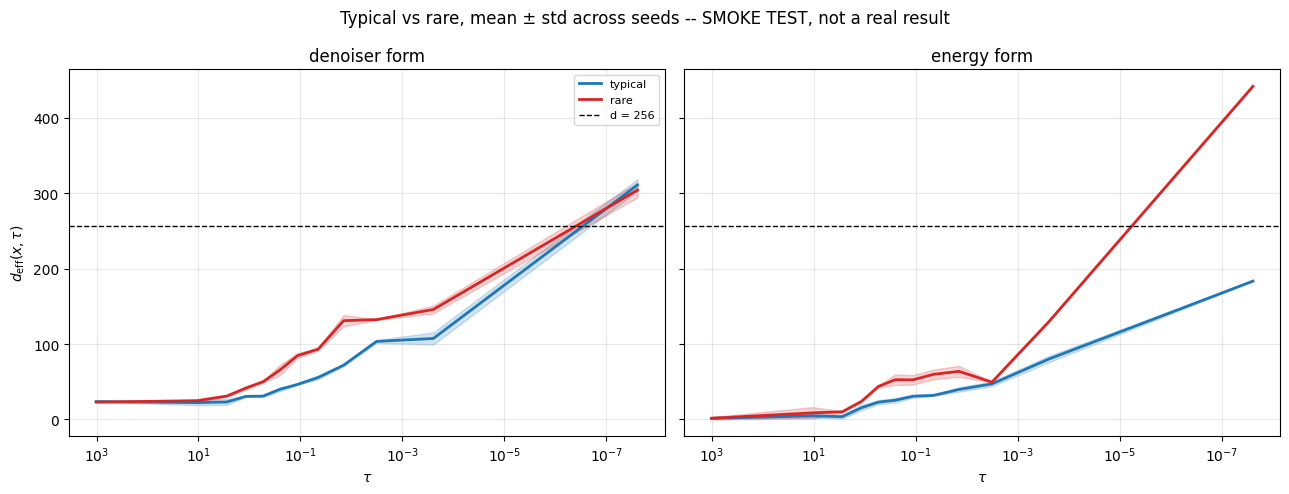

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, col, title in [(axes[0], 'd_eff_denoiser', 'denoiser form'),
                        (axes[1], 'd_eff_energy', 'energy form')]:
    for cat in ['typical', 'rare']:
        sub = results_df[results_df.category == cat]
        per_seed = sub.groupby(['seed', 'tau'])[col].mean().reset_index()
        stats = per_seed.groupby('tau')[col].agg(['mean', 'std']).sort_index()
        ax.plot(stats.index, stats['mean'], color=colors[cat], lw=2, label=cat)
        ax.fill_between(stats.index, stats['mean'] - stats['std'], stats['mean'] + stats['std'],
                         color=colors[cat], alpha=0.2)
    ax.axhline(d, color='k', ls='--', lw=1, label=f'd = {d}')
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.set_xlabel(r'$\tau$')
    ax.set_title(title)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$d_{\rm eff}(x,\tau)$')
axes[0].legend(fontsize=8)
fig.suptitle('Typical vs rare, mean ± std across seeds'
             + (' -- SMOKE TEST, not a real result' if SMOKE_TEST else ''))
fig.tight_layout()
plt.show()


## Caveats (see `notes/effective_dimension_MGD.tex` for the full derivation)

- **Denoiser form is the primary estimator.** It needs only $\Theta_{\rm
  reg}$ and $\nabla\varphi$; no $\log Z_t$, no $m_t$, no normalisation
  constant enters (it cancels analytically).
- **Energy form is a secondary cross-check, not an independent estimate.**
  `energy_d_eff` differentiates $\log Z_t \approx H_{\rm bound}(t) +
  \theta_t^\top m_t$ (MGD Eq. 8/30) -- a *lower bound* on $\log Z_t$, not
  $\log Z_t$ itself -- with a finite difference on a Monte-Carlo-noisy
  curve, so it inherits both the bound's bias and extra numerical noise
  from the derivative. Expect it to be visibly noisier than the denoiser
  form at the same `N_MC`; increase `N_MC` and/or `N_T_SUB` before trusting
  it quantitatively.
- **The last few $t_{\rm reg}$ nodes ($\tau\to0$) use the most
  ill-conditioned $\theta$** (one dominant, near-null-direction
  coefficient at $t\to1$ in every seed inspected so far) -- treat the
  smallest-$\tau$ end of every curve as the least numerically trustworthy,
  not the most informative, until cross-checked against a finer grid /
  larger `N_MC`.
- `m_t_source` in `results_df` records whether $m_t$ came from
  `aux_moments` (pulled from Jean Zay) or was recomputed locally from
  `x1` -- both should agree up to Monte Carlo noise; worth checking once
  `aux_moments` is available.
